# 01 · Análisis Exploratorio — Operaciones de Tienda
**Cadena de retail multi-región (México) · enero 2023 – febrero 2024**

Contamos con tres insumos: **transacciones** diarias por tienda × categoría, **catálogo de tiendas** y **calendario** de eventos. La tarea es abierta: definir un problema de negocio y construir una solución basada en datos.

Este notebook cumple cuatro objetivos, en orden:

1. **Sanidad y calidad** — validar la integridad del panel y entender los datos faltantes.
2. **Dinámica del negocio** — estacionalidad, heterogeneidad de tiendas y mezcla de categorías.
3. **Auditoría de dos sistemas visibles en los datos** — la señal de reposición de inventario y las promociones.
4. **Síntesis** — aterrizar los hallazgos en una propuesta de solución con caso de negocio.

> Las funciones de carga, calidad y estilo viven en el paquete [`src/`](../src) para mantener el notebook enfocado en el análisis y el código reutilizable para la fase de modelado.

In [1]:
import sys, warnings
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, viz
from src.preprocesamiento.data import load_transactions, load_stores, load_calendar, build_master
from src.preprocesamiento.quality import missing_summary, grid_gaps, payment_consistency

warnings.filterwarnings("ignore")
viz.apply_style()
pd.set_option("display.max_columns", 40)

In [2]:
tx = load_transactions()
stores = load_stores()
cal = load_calendar()

print(f"transactions: {len(tx):,} filas × {tx.shape[1]} cols")
print(f"stores:       {len(stores)} tiendas")
print(f"calendar:     {len(cal)} días  ({cal.date.min().date()} → {cal.date.max().date()})")
tx.head(3)

transactions: 203,958 filas × 13 cols
stores:       80 tiendas
calendar:     425 días  (2023-01-01 → 2024-02-29)


,date,store_id,category,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,avg_ticket,has_promotion,replenishment_signal
0,2023-01-01,STR_001,Abarrotes,833,NaN,326,244732.98,NaN,101822.79,2299.0,NaN,0,NaN
1,2023-01-02,STR_001,Abarrotes,1298,750.0,548,373235.09,222834.25,150400.84,3011.0,287.55,0,NaN
2,2023-01-03,STR_001,Abarrotes,1614,931.0,683,404249.92,239802.59,164447.33,3652.0,250.46,0,1546.0


## 1 · Sanidad del panel

La granularidad es **tienda × categoría × día**: 80 tiendas × 6 categorías × 425 días = 204,000 celdas esperadas.

In [3]:
n_expected = tx.store_id.nunique() * tx.category.nunique() * tx.date.nunique()
print(f"Completitud del panel: {len(tx):,} / {n_expected:,} = {len(tx)/n_expected:.2%}")
print(f"Duplicados (tienda, categoría, día): {tx.duplicated(config.PANEL_KEYS).sum()}\n")

grid_gaps(tx)

Completitud del panel: 203,958 / 204,000 = 99.98%
Duplicados (tienda, categoría, día): 0



,store_id,n_dias_faltantes,fechas
0,STR_045,2,"[2023-02-01, 2023-02-02]"
1,STR_055,3,"[2024-02-18, 2024-02-19, 2024-02-20]"
2,STR_064,2,"[2023-02-22, 2023-02-23]"


**El panel está 99.98% completo y sin duplicados.** Solo 3 tiendas tienen días caídos por completo (2–3 días consecutivos cada una, consistente con fallas de POS/conectividad). Son huecos pequeños y acotados: para series de tiempo se pueden imputar o simplemente dejar como huecos explícitos.

## 2 · Calidad de datos

### 2.1 Nulos por columna

In [4]:
missing_summary(tx)

,n_nulos,pct_nulos
cash_transactions,12123,5.94
amount_cash,12123,5.94
units_sold,6118,3.00
avg_ticket,4874,2.39
replenishment_signal,960,0.47


In [5]:
# ¿Dónde están los nulos de replenishment_signal en el tiempo?
rs_null = tx.groupby("date").replenishment_signal.apply(lambda s: s.isnull().mean())
print("Días con nulos en replenishment_signal:")
print(rs_null[rs_null > 0])

Días con nulos en replenishment_signal:
date
2023-01-01    1.0
2023-01-02    1.0
Name: replenishment_signal, dtype: float64


Los nulos de pago en efectivo (~5.9%) y unidades (~3%) están repartidos entre tiendas y fechas — consistente con fallas aleatorias de POS, no con un sesgo sistemático.

Dato curioso: el diccionario dice que `replenishment_signal` puede tener nulos *"en los últimos días del periodo"*, pero en realidad **los únicos nulos están en los 2 primeros días**. Eso es exactamente lo que pasaría si la señal se calcula **mirando hacia atrás** (sin historia, no hay señal). Primera pista de algo que confirmaremos en la sección 6.

### 2.2 Identidades contables

In [6]:
payment_consistency(tx)

,pct_filas_cumplen,pct_en_dias_promo,pct_en_dias_sin_promo
monto: total == cash + card,100.00,100.0,100.0
conteo: total == cash + card,80.04,0.0,100.0
avg_ticket == monto / total_transactions,80.04,0.0,100.0
avg_ticket == monto / pagadas (cash+card),100.00,100.0,100.0


**Hallazgo 1 — "transacciones fantasma" en días de promoción.**

- Los **montos** cuadran exacto (`amount_total = amount_cash + amount_card`) en **todas las filas verificables** — el 94.1% donde `amount_cash` existe. El 5.9% restante no es verificable porque `amount_cash` es nulo; en la sección 2.3 se analiza si esos nulos esconden algo.
- El **conteo** de transacciones solo cuadra en días sin promoción: con promoción activa, `total_transactions > cash + card` en el 100% de los casos.
- `avg_ticket` no es `amount_total / total_transactions`: es `amount_total / (cash + card)` — el sistema calcula el ticket **solo sobre transacciones pagadas**.

Es decir: en días de promoción se registran transacciones **sin método de pago y sin monto asociado**. Veamos su magnitud:

In [7]:
d = tx.dropna(subset=["cash_transactions"]).copy()
d["extra"] = d.total_transactions - d.cash_transactions - d.card_transactions

resumen = d.groupby("has_promotion").agg(
    filas=("extra", "size"),
    pct_filas_con_extra=("extra", lambda s: f"{(s > 0).mean():.0%}"),
    transacciones_extra_promedio=("extra", "mean"),
).round(1)
resumen.index = ["Sin promoción", "Con promoción"]
print(resumen, "\n")

con_extra = d[d.extra > 0]
share = con_extra.extra / con_extra.total_transactions
print(f"En días con promoción, {share.mean():.1%} del total_transactions reportado "
      f"no tiene pago asociado (rango típico {share.quantile(.25):.0%}–{share.quantile(.75):.0%}).")

                filas pct_filas_con_extra  transacciones_extra_promedio
Sin promoción  153540                  0%                           0.0
Con promoción   38295                100%                         131.1 

En días con promoción, 17.9% del total_transactions reportado no tiene pago asociado (rango típico 14%–22%).


La interpretación más plausible: son **canjes de promoción / cupones** que el POS registra como transacción pero sin venta. Implicaciones prácticas:

- `total_transactions` **no es comparable** entre días con y sin promoción → para medir tráfico real usar `cash + card`.
- Cualquier métrica de conversión o ticket construida sobre `total_transactions` estará sesgada a la baja en promociones.

Guardamos este hallazgo: reaparece en la sección 7 al evaluar la efectividad de las promociones.

### 2.3 · Los nulos de `amount_cash`: ¿aleatorios o estructurales?

La identidad de montos solo se puede *verificar* donde `amount_cash` existe. Antes de descartar el 5.9% no verificable hay que responder tres preguntas: ¿los nulos dependen de la promoción?, ¿se concentran en algún corte?, ¿el valor faltante es reconstruible?

In [8]:
nulos = tx.amount_cash.isnull()
print(f"Filas con amount_cash nulo: {nulos.sum():,} ({nulos.mean():.2%})")
print("cash_transactions falta exactamente en las mismas filas:",
      (tx.cash_transactions.isnull() == nulos).all())
print("amount_total y amount_card están SIEMPRE presentes:",
      tx.amount_total.notna().all() and tx.amount_card.notna().all())

# 1) ¿Dependen de la promoción? (test de dos proporciones)
t = tx.groupby("has_promotion").amount_cash.apply(lambda s: s.isnull().mean())
n = tx.groupby("has_promotion").size()
p = nulos.mean()
z = (t[1] - t[0]) / np.sqrt(p * (1 - p) * (1 / n[0] + 1 / n[1]))
print(f"\n1) Tasa de nulos sin promo: {t[0]:.2%} | con promo: {t[1]:.2%}  (z = {z:.2f}: "
      f"{'indistinguible del azar' if abs(z) < 2 else 'DIFERENCIA SIGNIFICATIVA'})")

# 2) ¿Se concentran en algún corte?
for corte in ["store_id", "category"]:
    tasa = tx.groupby(corte, observed=True).amount_cash.apply(lambda s: s.isnull().mean())
    print(f"2) Tasa por {corte}: min {tasa.min():.1%} · max {tasa.max():.1%}")
tasa_mes = tx.groupby(tx.date.dt.to_period("M")).amount_cash.apply(lambda s: s.isnull().mean())
print(f"   Tasa por mes: min {tasa_mes.min():.1%} · max {tasa_mes.max():.1%}")

# 3) ¿El valor faltante es reconstruible?  cash implícito = total − card
imp = tx.loc[nulos, "amount_total"] - tx.loc[nulos, "amount_card"]
share_obs = (tx.loc[~nulos, "amount_cash"] / tx.loc[~nulos, "amount_total"]).mean()
share_imp = (imp / tx.loc[nulos, "amount_total"]).mean()
print(f"\n3) Participación del efectivo — observada: {share_obs:.1%} | "
      f"implícita en las filas nulas: {share_imp:.1%}")
print(f"   Montos implícitos negativos: {(imp < 0).sum()}")
print(f"   Venta media de filas nulas vs no nulas: "
      f"{tx.loc[nulos, 'amount_total'].mean():,.0f} vs {tx.loc[~nulos, 'amount_total'].mean():,.0f}")

Filas con amount_cash nulo: 12,123 (5.94%)


cash_transactions falta exactamente en las mismas filas: True
amount_total y amount_card están SIEMPRE presentes: True

1) Tasa de nulos sin promo: 5.93% | con promo: 6.01%  (z = 0.66: indistinguible del azar)
2) Tasa por store_id: min 4.9% · max 7.0%
2) Tasa por category: min 5.8% · max 6.1%
   Tasa por mes: min 5.6% · max 6.4%

3) Participación del efectivo — observada: 41.7% | implícita en las filas nulas: 41.6%
   Montos implícitos negativos: 0
   Venta media de filas nulas vs no nulas: 172,387 vs 170,467


**Veredicto: faltantes completamente aleatorios (MCAR) y reconstruibles — es seguro despriorizarlos.** La evidencia:

1. **No dependen de la promoción**: 5.93% de nulos sin promo vs 6.01% con promo (z ≈ 0.7, indistinguible del azar). Si los nulos escondieran manipulación ligada a promociones, esta tasa diferiría.
2. **No se concentran en nada**: la tasa es ~6% pareja en las 80 tiendas (4.9–7.0%), las 6 categorías y los 14 meses — patrón de fallas aleatorias de POS, no de un subsistema o periodo dañado.
3. **El valor faltante es reconstruible por contabilidad**: como `amount_total` y `amount_card` nunca faltan, el efectivo implícito es `total − card`. Ese implícito se comporta *exactamente* como el observado (participación del efectivo 41.6% vs 41.7%, cero negativos, misma venta media) — las filas nulas no son días raros, son días normales a los que solo se les cayó el campo de efectivo.

Matiz de honestidad: en estas filas la identidad contable no es *verificable* (el implícito se define con la propia identidad, sería circular). Lo que sí se puede afirmar: nada en ellas es anómalo ni sesga el análisis. Para el modelo de demanda son irrelevantes — el target es `units_sold` y el desglose efectivo/tarjeta no participa en el pronóstico; si un análisis futuro de mezcla de pagos las necesitara, la imputación `total − card` es exacta bajo el supuesto (verificado en el 94%) de que solo existen dos métodos de pago.

## 3 · Dinámica temporal

### 3.1 La venta de la cadena, día a día

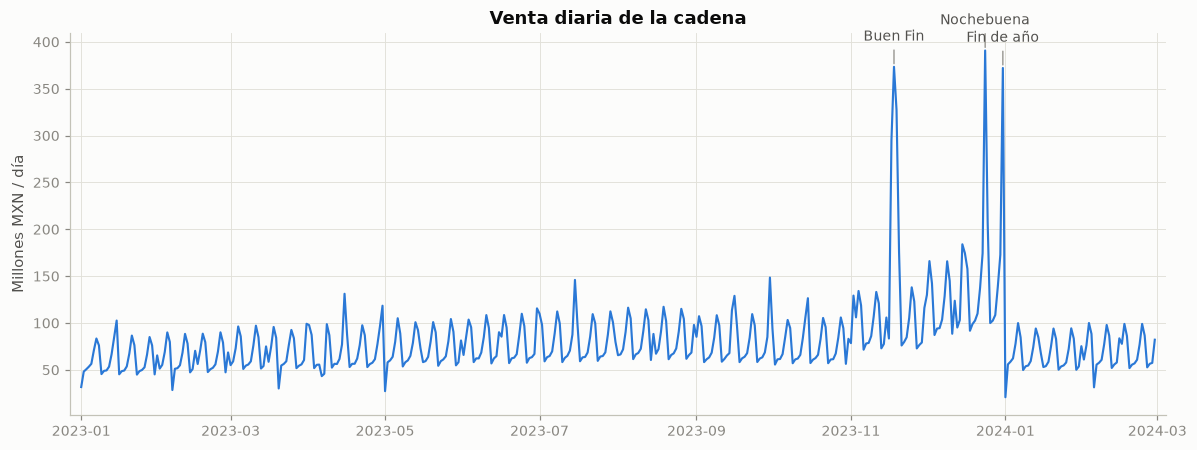

In [9]:
daily = tx.groupby("date").amount_total.sum() / 1e6

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(daily.index, daily.values, color=viz.ACCENT, lw=1.4)

eventos = {"2023-11-18": "Buen Fin", "2023-12-24": "Nochebuena", "2023-12-31": "Fin de año"}
for f, nombre in eventos.items():
    f = pd.Timestamp(f)
    ax.annotate(nombre, xy=(f, daily.loc[f]), xytext=(f, daily.loc[f] + 28),
                ha="center", fontsize=9, color=viz.INK_SECONDARY,
                arrowprops=dict(arrowstyle="-", color=viz.INK_MUTED, lw=0.8))
ax.set_title("Venta diaria de la cadena")
ax.set_ylabel("Millones MXN / día")
ax.margins(x=0.01)
plt.tight_layout()

### 3.2 ¿Cuánto pesa cada tipo de día?

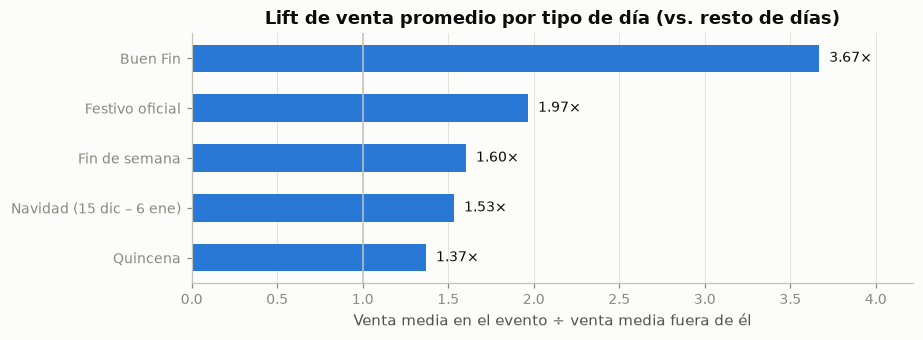

In [10]:
txc = tx.merge(cal, on="date")

def lift(mask):
    return txc[mask].amount_total.mean() / txc[~mask].amount_total.mean()

lifts = pd.Series({
    "Buen Fin": lift(txc.is_buen_fin),
    "Fin de semana": lift(txc.is_weekend),
    "Navidad (15 dic – 6 ene)": lift(txc.is_navidad_season),
    "Quincena": lift(txc.is_payday),
    "Festivo oficial": lift(txc.is_holiday),
}).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 3.2))
bars = ax.barh(lifts.index, lifts.values, color=viz.ACCENT, height=0.55)
ax.axvline(1, color=viz.BASELINE, lw=1)
for b, v in zip(bars, lifts.values):
    ax.text(v + 0.06, b.get_y() + b.get_height() / 2, f"{v:.2f}×",
            va="center", fontsize=9, color=viz.INK)
ax.set_xlim(0, lifts.max() * 1.15)
ax.set_title("Lift de venta promedio por tipo de día (vs. resto de días)")
ax.set_xlabel("Venta media en el evento ÷ venta media fuera de él")
ax.grid(axis="y", visible=False)
plt.tight_layout()

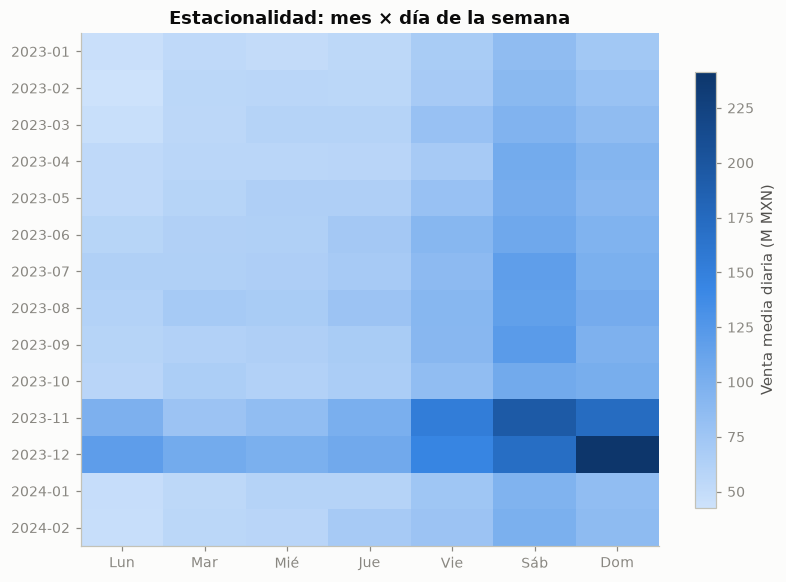

In [11]:
# Heatmap mes × día de la semana (promedio de venta diaria de la cadena)
dtot = txc.groupby("date").agg(venta=("amount_total", "sum"), dow=("day_of_week", "first"))
dtot["ym"] = dtot.index.to_period("M").astype(str)
hm = dtot.groupby(["ym", "dow"]).venta.mean().unstack() / 1e6

fig, ax = plt.subplots(figsize=(7.5, 5.4))
im = ax.imshow(hm.values, aspect="auto", cmap=viz.SEQUENTIAL_CMAP)
ax.set_xticks(range(7))
ax.set_xticklabels(["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"])
ax.set_yticks(range(len(hm)))
ax.set_yticklabels(hm.index)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Venta media diaria (M MXN)", shrink=0.85)
ax.set_title("Estacionalidad: mes × día de la semana")
plt.tight_layout()

**La demanda es altamente estructurada y predecible:**

- **Sábado y domingo** concentran la venta (fin de semana 1.60×; el sábado casi duplica al lunes).
- **Quincenas** suben la venta 1.37× — patrón clásico de consumo mexicano.
- **El Buen Fin es el evento dominante del año: 3.67×** la venta de un día normal, sostenido 4 días. Noviembre–diciembre concentran todos los picos del año.
- El patrón semanal es estable mes a mes (franjas verticales del heatmap): hay mucha señal aprovechable para un modelo de pronóstico.

## 4 · Heterogeneidad de tiendas

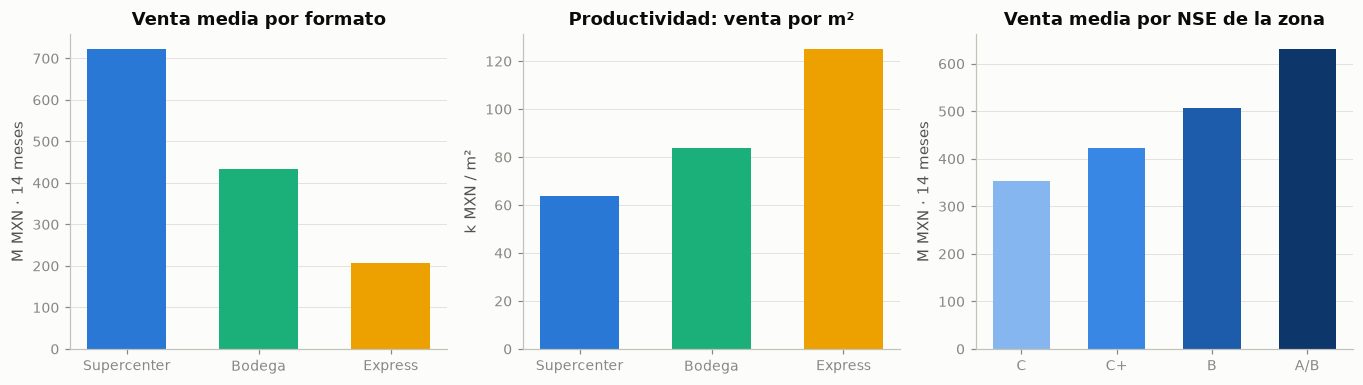

In [12]:
rev = tx.groupby("store_id").amount_total.sum().rename("rev_total")
stx = stores.merge(rev, on="store_id")
stx["rev_por_m2"] = stx.rev_total / stx.size_sqm

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))

f = stx.groupby("store_format", observed=True).rev_total.mean() / 1e6
axes[0].bar(f.index.astype(str), f.values, width=0.6,
            color=[viz.FORMAT_COLORS[x] for x in f.index])
axes[0].set_title("Venta media por formato")
axes[0].set_ylabel("M MXN · 14 meses")

p = stx.groupby("store_format", observed=True).rev_por_m2.mean() / 1e3
axes[1].bar(p.index.astype(str), p.values, width=0.6,
            color=[viz.FORMAT_COLORS[x] for x in p.index])
axes[1].set_title("Productividad: venta por m²")
axes[1].set_ylabel("k MXN / m²")

nse = stx.groupby("socioeconomic_level", observed=True).rev_total.mean() / 1e6
axes[2].bar(nse.index.astype(str), nse.values, width=0.6, color=viz.ORDINAL_STEPS)
axes[2].set_title("Venta media por NSE de la zona")
axes[2].set_ylabel("M MXN · 14 meses")

for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()

In [13]:
sr = stx.set_index("store_id").rev_total.sort_values()
print(f"Dispersión entre tiendas: la mayor vende {sr.iloc[-1] / sr.iloc[0]:.1f}× lo de la menor")
print(f"  · Mínima: {sr.index[0]} — {sr.iloc[0] / 1e6:,.0f} M MXN")
print(f"  · Máxima: {sr.index[-1]} — {sr.iloc[-1] / 1e6:,.0f} M MXN")

Dispersión entre tiendas: la mayor vende 7.5× lo de la menor
  · Mínima: STR_059 — 155 M MXN
  · Máxima: STR_017 — 1,166 M MXN


- **Supercenter** vende ~3.5× lo de un Express en absoluto, pero **Express duplica a Supercenter en venta por m²** — formatos con economías distintas.
- El **NSE de la zona ordena la venta de forma monótona** (A/B > B > C+ > C).
- La dispersión total es de **7.5×** entre tiendas: cualquier modelo debe capturar esta heterogeneidad (formato, tamaño, NSE, región) y cualquier pronóstico debe evaluarse **por tienda**, no solo agregado.

## 5 · Mezcla de categorías

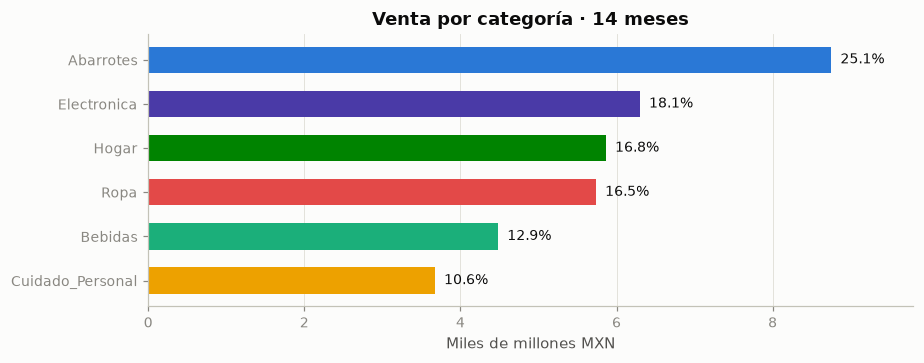

Estabilidad de la mezcla — desv. est. de la participación mensual (puntos %):
category
Abarrotes           0.07
Electronica         0.07
Ropa                0.06
Cuidado_Personal    0.05
Bebidas             0.04
Hogar               0.04


In [14]:
mix = tx.groupby("category").amount_total.sum().sort_values()
share = mix / mix.sum()

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.barh(mix.index.astype(str), mix.values / 1e9, height=0.6,
        color=[viz.CATEGORY_COLORS[c] for c in mix.index])
for i, (v, s) in enumerate(zip(mix.values / 1e9, share.values)):
    ax.text(v + 0.12, i, f"{s:.1%}", va="center", fontsize=9, color=viz.INK)
ax.set_xlim(0, mix.max() / 1e9 * 1.12)
ax.set_title("Venta por categoría · 14 meses")
ax.set_xlabel("Miles de millones MXN")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

m_share = txc.assign(ym=txc.date.dt.to_period("M").astype(str)) \
             .pivot_table(index="ym", columns="category", values="amount_total", aggfunc="sum")
m_share = m_share.div(m_share.sum(axis=1), axis=0)
print("Estabilidad de la mezcla — desv. est. de la participación mensual (puntos %):")
print((m_share.std() * 100).round(2).sort_values(ascending=False).to_string())

Abarrotes lidera con ~25% de la venta; la mezcla es **muy estable en el tiempo** (la participación mensual de cada categoría varía menos de 1 punto porcentual). Los picos estacionales suben la marea para todas las categorías por igual — la estructura del problema es la misma en las 480 series tienda × categoría.

## 6 · La señal de reposición es reactiva (hallazgo central)

`replenishment_signal` es la señal que genera el sistema de reposición de inventario de cada tienda, *"calculada internamente con base en la demanda observada"*. La pregunta clave: **¿mira hacia adelante (pronostica) o hacia atrás (reacciona)?**

Para aislar la estructura temporal, estandarizamos cada serie tienda × categoría (z-score) y correlacionamos la señal de hoy con las unidades vendidas de días anteriores:

corr(señal_t , media móvil 7d de unidades hasta t−1) = 0.872



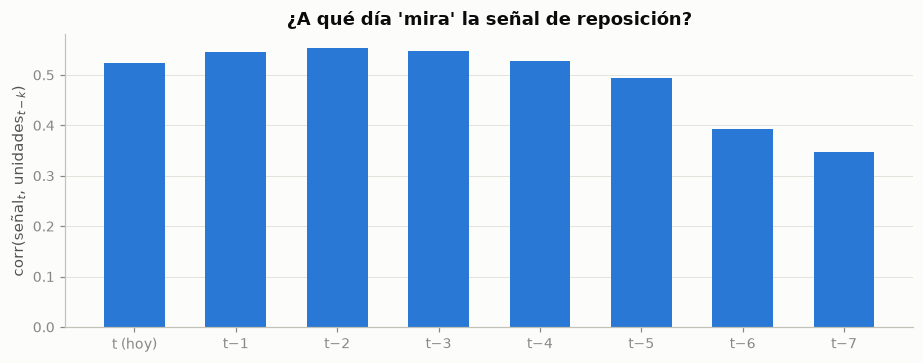

In [15]:
txs = tx.sort_values(["store_id", "category", "date"]).reset_index(drop=True)
g = txs.groupby(["store_id", "category"], observed=True)

txs["units_z"] = (txs.units_sold - g.units_sold.transform("mean")) / g.units_sold.transform("std")
txs["rs_z"] = (txs.replenishment_signal - g.replenishment_signal.transform("mean")) \
              / g.replenishment_signal.transform("std")

gz = txs.groupby(["store_id", "category"], observed=True)["units_z"]
corr_lag = pd.Series({lag: txs.rs_z.corr(gz.shift(lag)) for lag in range(8)})

ma7 = gz.shift(1).rolling(7).mean()
print(f"corr(señal_t , media móvil 7d de unidades hasta t−1) = {txs.rs_z.corr(ma7):.3f}\n")

fig, ax = plt.subplots(figsize=(8.5, 3.4))
etiquetas = ["t (hoy)"] + [f"t−{l}" for l in range(1, 8)]
ax.bar(etiquetas, corr_lag.values, color=viz.ACCENT, width=0.6)
ax.set_title("¿A qué día 'mira' la señal de reposición?")
ax.set_ylabel("corr(señal$_t$, unidades$_{t-k}$)")
ax.grid(axis="x", visible=False)
plt.tight_layout()

La señal correlaciona más con las ventas de **hace 1–3 días** que con las de hoy, y correlaciona **0.85+ con la media móvil de 7 días de la demanda pasada**. Conclusión: el sistema de reposición actual es, en esencia, **un promedio móvil que persigue a la demanda**. Y eso tiene un costo muy concreto en los picos:

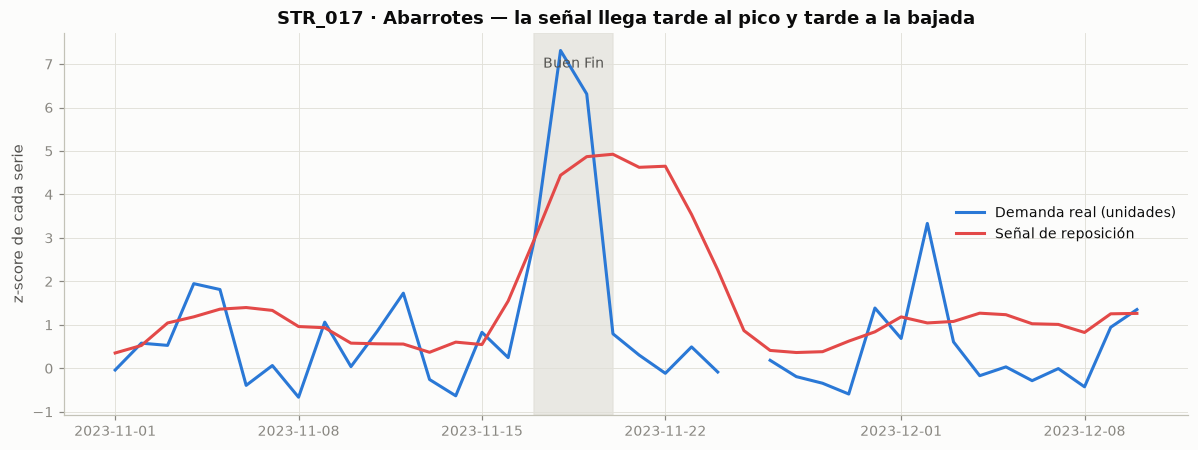

In [16]:
s = txs[(txs.store_id == "STR_017") & (txs.category == "Abarrotes")]
win = s[(s.date >= "2023-11-01") & (s.date <= "2023-12-10")]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axvspan(pd.Timestamp("2023-11-17"), pd.Timestamp("2023-11-20"),
           color=viz.GRID, alpha=0.7, zorder=0)
ax.plot(win.date, win.units_z, color=viz.ACCENT, label="Demanda real (unidades)")
ax.plot(win.date, win.rs_z, color=viz.ACCENT_ALT, label="Señal de reposición")
ax.text(pd.Timestamp("2023-11-18 12:00"), ax.get_ylim()[1] * 0.93, "Buen Fin",
        ha="center", va="top", fontsize=9, color=viz.INK_SECONDARY)
ax.legend(loc="center right")
ax.set_title("STR_017 · Abarrotes — la señal llega tarde al pico y tarde a la bajada")
ax.set_ylabel("z-score de cada serie")
plt.tight_layout()

In [17]:
idx = txs.merge(cal[["date", "is_buen_fin"]], on="date")
gm = idx.groupby(["store_id", "category"], observed=True)
idx["units_idx"] = idx.units_sold / gm.units_sold.transform("mean")
idx["rs_idx"] = idx.replenishment_signal / gm.replenishment_signal.transform("mean")
idx = idx.sort_values(["store_id", "category", "date"])
idx["post_pico"] = idx.groupby(["store_id", "category"], observed=True) \
                      .is_buen_fin.shift(3).fillna(False).astype(bool)

ventanas = {
    "Buen Fin (pico)": idx.is_buen_fin,
    "3 días después del pico": idx.post_pico & ~idx.is_buen_fin,
    "Días normales": ~idx.is_buen_fin & ~idx.post_pico,
}
resumen = pd.DataFrame({
    nombre: {
        "Demanda (índice vs. su media)": idx[m].units_idx.mean(),
        "Señal de reposición (índice)": idx[m].rs_idx.mean(),
    }
    for nombre, m in ventanas.items()
}).T.round(2)
resumen["brecha (demanda − señal)"] = (resumen.iloc[:, 0] - resumen.iloc[:, 1]).round(2)
resumen

,Demanda (índice vs. su media),Señal de reposición (índice),brecha (demanda − señal)
Buen Fin (pico),3.44,2.26,1.18
3 días después del pico,0.98,2.29,-1.31
Días normales,0.98,0.98,0.00


**Hallazgo 2 — el costo de reponer mirando por el retrovisor:**

| Momento | Demanda | Señal | Consecuencia |
|---|---|---|---|
| Buen Fin | **3.4×** su nivel normal | solo 2.3× | la señal **sub-estima ~34%** la demanda → riesgo de quiebre de inventario en los 4 días más valiosos del año |
| 3 días después | ya volvió a 1.0× | sigue en **2.3×** | el sistema pide **más del doble de lo necesario** → sobre-inventario, capital inmovilizado y merma |

Los picos son **100% previsibles** (Buen Fin, Navidad, quincenas están en el calendario), pero el sistema actual no usa el calendario: solo reacciona al pasado. **Esta es la oportunidad de negocio.**

> ⚠️ Nota de modelado: como `replenishment_signal` se deriva de la demanda observada, usarla como *feature* contemporánea en un modelo de pronóstico sería **fuga de información** (leakage). Su rol correcto es de **baseline a vencer**: representa al sistema actual.

## 7 · Promociones: mucho movimiento, cero venta incremental

In [18]:
promo = tx.groupby("has_promotion").agg(
    venta_media=("amount_total", "mean"),
    unidades_media=("units_sold", "mean"),
    ticket_medio=("avg_ticket", "mean"),
).round(1)
promo.index = ["Sin promoción", "Con promoción"]
promo.loc["Lift"] = (promo.loc["Con promoción"] / promo.loc["Sin promoción"] - 1) \
                     .map(lambda v: f"{v:+.1%}")
print(f"Días tienda-categoría con promoción: {tx.has_promotion.mean():.1%}")
print("Participación de promos por categoría (¿focalización?):")
print(tx.groupby("category", observed=True).has_promotion.mean().round(3).to_string())
promo

Días tienda-categoría con promoción: 20.0%
Participación de promos por categoría (¿focalización?):
category
Abarrotes           0.199
Bebidas             0.200
Cuidado_Personal    0.199
Hogar               0.202
Electronica         0.200
Ropa                0.199


,venta_media,unidades_media,ticket_medio
Sin promoción,170566.5,1174.6,411.9
Con promoción,170640.3,1178.8,411.0
Lift,+0.0%,+0.4%,-0.2%


**Hallazgo 3 — las promociones no generan venta incremental.**

- El 20% de los días tienda-categoría tienen promoción, repartida de forma **uniforme** entre categorías, tiendas y fechas — no hay focalización aparente.
- El lift en venta es **+0.0%** y en unidades **+0.4%**: estadísticamente nada.
- Lo único que crece es `total_transactions` (+22%)… que como vimos en el Hallazgo 1 son **registros sin pago** (canjes/cupones), no clientes comprando más.

Dos lecturas posibles, ambas accionables: (a) las promociones realmente no funcionan y hay que **rediseñar la mecánica promocional** (es gasto sin retorno), o (b) el flag `has_promotion` no refleja promociones reales de precio. En cualquier caso, es un *quick win* de rentabilidad que sale gratis de esta auditoría.

## 8 · Síntesis y propuesta de solución

### Lo que sabemos

| # | Hallazgo | Implicación |
|---|----------|-------------|
| 1 | En días de promo, ~18% de `total_transactions` son registros sin pago | Medir tráfico con `cash + card`; auditar registro de canjes |
| 2 | La señal de reposición es una media móvil reactiva: sub-surte 34% en picos y sobre-surte 2.3× después | **Núcleo de la solución**: pronóstico predictivo |
| 3 | Las promociones no generan venta incremental | Quick win: rediseñar mecánica promocional |
| 4 | La demanda es altamente estructurada (semana, quincena, Buen Fin 3.7×, Navidad) | El calendario tiene enorme poder predictivo — y el sistema actual lo ignora |
| 5 | Heterogeneidad 7.5× entre tiendas, ordenada por formato/NSE/tamaño | Los atributos de tienda son features; evaluar por tienda |
| 6 | Datos faltantes acotados y manejables (≤6%, mayormente aleatorios) | Pipeline de imputación simple y explícito |

### La propuesta: **pronóstico de demanda por tienda × categoría para reposición inteligente**

Un modelo que pronostica `units_sold` a horizonte de 1–14 días para las 480 series tienda × categoría, usando los **tres insumos**:

- **`transactions`** → historia de demanda (target + rezagos/ventanas móviles)
- **`calendar`** → los drivers que el sistema actual ignora: día de semana, quincena, Buen Fin, Navidad, festivos
- **`stores`** → formato, tamaño, NSE, región para capturar la heterogeneidad y compartir señal entre tiendas similares

**Cómo se valida** (implementado en el pipeline, ver notebook `02_resultados`):

1. **Backtesting temporal** (walk-forward): entrenar hasta *t*, pronosticar *t+1…t+14*, rodar la ventana. Sin fuga de información: `replenishment_signal` queda excluida como feature.
2. **Baselines a vencer**: (a) naïve estacional (misma tienda-categoría, mismo día de semana), (b) la propia `replenishment_signal` reescalada — es decir, **el sistema actual**.
3. **Métricas**: WAPE/MAE por serie y agregado; y separado en **días pico vs. normales**, porque ahí vive el valor.
4. **Caso de negocio**: traducir la reducción de error en picos a venta recuperada (menos quiebres en Buen Fin/Navidad) y a inventario evitado post-pico.

El valor es medible contra el sistema actual con los mismos datos: si el pronóstico reduce la brecha de 34% en picos, la venta recuperada se estima directamente sobre los ~3.7× de venta de esos días.